# Bayesian Optimization — Function 2 (2D, Improved)

This notebook runs one step of Bayesian Optimization on a **2-dimensional** black-box function.

### Improvements over the original F2 script

| Area | Original | Improved |
|---|---|---|
| **Seed** | None | `np.random.default_rng(42)` |
| **Data path** | Hardcoded Windows path | `pathlib.Path(".")` — portable |
| **Data loading** | Loads all 8 functions, uses only F2 | Loads F2 only |
| **y transform** | None | None needed (y is well-scaled: -0.07 to 0.61) |
| **Kernel** | RBF | Matérn ν=2.5 |
| **xi** | Fixed at 0 (pure exploitation) | Adaptive (starts at 0.05, decays) |
| **Sampling** | 50k pure random | 10k Sobol quasi-random (sufficient for 2D) |
| **L-BFGS-B starts** | 5 | 8 |
| **Acquisition** | EI only | EI or UCB (switchable) |
| **Structure** | One-shot script | Full BO loop with history tracking |
| **Visualization** | None | GP mean, std, EI heatmaps + convergence plot |

## 1. Imports & Configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel
from scipy.stats import norm, qmc
from scipy.optimize import minimize

# ── SVM: Classify high vs low regions ────────────────────────────────────────
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# ── Neural Network: MC-Dropout surrogate ─────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
rng  = np.random.default_rng(SEED)
torch.manual_seed(SEED)

## 2. Data Loading

The original script loaded all 8 functions simultaneously but only used F2. This has been cleaned up to load F2 only.

F2's output values range from approximately `-0.07` to `0.61` — a **well-scaled, normal range** with no extreme values. Unlike F1 (which had outputs as small as `1e-79`), **no log-transform is needed here**. The GP can be fitted directly on the raw y values.

In [2]:
# ── Portable data loading ─────────────────────────────────────────────────────
# Place initial_inputs.npy / initial_outputs.npy next to this notebook,
# OR change DATA_DIR to wherever the F2 data lives.
DATA_DIR = Path("C:\\Users\\fakep\\OneDrive\\Bureau\\CAPSTONE\\function_2\\")    # <-- edit if needed

X = np.load(DATA_DIR / "initial_inputs.npy")
y = np.load(DATA_DIR / "initial_outputs.npy")

n_dim = X.shape[1]
print(f"Loaded {len(y)} observations, {n_dim} dimensions.")
print(f"y range : [{y.min():.4f}, {y.max():.4f}]")
print(f"Current best y = {y.max():.6f}  (at index {y.argmax()})")

Loaded 10 observations, 2 dimensions.
y range : [-0.0656, 0.6112]
Current best y = 0.611205  (at index 9)


## 3. Gaussian Process Model

We use a **Matérn ν=2.5 kernel** instead of the original RBF. The key difference is:
- **RBF** assumes the function is infinitely differentiable — often too smooth an assumption for real-world black-box functions
- **Matérn 5/2** only assumes twice differentiability, which is more realistic and tends to generalise better in practice

The kernel is composed of three parts:
1. `ConstantKernel` — scales the overall output variance
2. `Matern` — models the spatial correlation between points
3. `WhiteKernel` — accounts for observation noise

In [3]:
def build_gp(n_dim: int) -> GaussianProcessRegressor:
    kernel = (
        C(1.0, constant_value_bounds=(1e-3, 1e5))
        * Matern(length_scale=[1.0] * n_dim,
                 length_scale_bounds=(1e-3, 1e3),
                 nu=2.5)
        + WhiteKernel(noise_level=1e-5,
                      noise_level_bounds=(1e-7, 1e-1))
    )
    return GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=25,
        alpha=1e-6,
        normalize_y=True,
    )

## 4. Acquisition Functions

Acquisition functions decide **where to sample next** by balancing exploration (uncertain regions) and exploitation (promising regions).

### Expected Improvement (EI)
EI computes the expected amount by which a candidate point will exceed the current best observation `y_max`:
$$EI(x) = (\mu(x) - y_{max} - \xi) \cdot \Phi(Z) + \sigma(x) \cdot \phi(Z), \quad Z = \frac{\mu(x) - y_{max} - \xi}{\sigma(x)}$$
where `ξ` (xi) controls the exploration-exploitation trade-off.

### Upper Confidence Bound (UCB)
UCB is simpler and sometimes more robust:
$$UCB(x) = \mu(x) + \kappa \cdot \sigma(x)$$
where `κ` controls how much uncertainty is rewarded.

### Adaptive xi
The original F2 script used `xi=0` — pure exploitation with no exploration bonus. This risks missing better regions of the 2D space that haven't been sampled yet. We instead start at `xi_init=0.05` and decay it over iterations, shifting gradually from exploration to exploitation as the dataset grows.

In [4]:
def expected_improvement(X_cand, gp, y_max, xi=0.01):
    """Expected Improvement — higher is better."""
    X_cand = np.atleast_2d(X_cand)
    mu, sigma = gp.predict(X_cand, return_std=True)
    sigma = np.maximum(sigma, 1e-8)
    imp   = mu - y_max - xi
    Z     = imp / sigma
    ei    = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma <= 1e-8] = 0.0
    return ei


def upper_confidence_bound(X_cand, gp, kappa=2.576):
    """UCB — higher kappa = more exploration."""
    X_cand = np.atleast_2d(X_cand)
    mu, sigma = gp.predict(X_cand, return_std=True)
    return mu + kappa * sigma


def adaptive_xi(iteration: int, xi_init=0.05, decay=0.85) -> float:
    """Decay xi over iterations for a smooth exploration → exploitation shift."""
    return max(xi_init * (decay ** iteration), 1e-4)

## 5. Next-Point Suggestion

We find the next point to evaluate in three steps:

1. **Sobol sampling** — generate `n_sobol` quasi-random candidates in [0,1]². Sobol sequences fill the space more uniformly than pure random sampling. In 2D, 10,000 points is more than sufficient (vs. 50,000 random in the original).
2. **Score & rank** — evaluate the acquisition function on all candidates and keep the top `n_best`.
3. **Local optimisation** — run L-BFGS-B from each of the top `n_best` starting points and return the global winner. This refinement step is crucial because Sobol candidates are discrete; L-BFGS-B finds the true local maximum of the acquisition surface.

In [5]:
def suggest_next_point(
    gp,
    y_max,
    n_dim,
    xi=0.01,
    n_sobol=10_000,   # 10k is sufficient for 2D
    n_best=8,         # 8 restarts is generous for 2D
    acq="ei",
    kappa=2.576,
    seed=None,
):
    # Step 1 — Sobol candidates
    sampler = qmc.Sobol(d=n_dim, scramble=True, seed=seed)
    X_cand  = sampler.random(n_sobol)

    # Step 2 — Score
    if acq == "ucb":
        scores = upper_confidence_bound(X_cand, gp, kappa=kappa)
    else:
        scores = expected_improvement(X_cand, gp, y_max, xi=xi)

    # Step 3 — Local optimisation from top-n_best starts
    starts = X_cand[np.argsort(scores)[-n_best:]]
    bounds = [(0, 1)] * n_dim

    if acq == "ucb":
        obj = lambda x: -upper_confidence_bound(x, gp, kappa=kappa).item()
    else:
        obj = lambda x: -expected_improvement(x, gp, y_max, xi=xi).item()

    best_x, best_score = None, -np.inf
    for x0 in starts:
        res = minimize(obj, x0=x0, bounds=bounds, method="L-BFGS-B")
        if -res.fun > best_score:
            best_score = -res.fun
            best_x     = res.x

    return best_x, best_score

## 6. 2D Visualisation Helper

One major advantage of working in 2D is that we can **visualise the GP surrogate** directly. The helper below produces a 3-panel plot:

- **Left** — GP posterior mean: what the model thinks the function looks like
- **Centre** — GP posterior std: where the model is uncertain
- **Right** — Acquisition function (EI or UCB): where the model wants to sample next

Observed points are shown as white dots; the suggested next point is shown as a red star. This plot is invaluable for diagnosing whether the optimizer is exploring sensibly.

> Since F2 outputs are in a normal range, the GP mean heatmap will directly reflect the raw function landscape — no back-transformation needed (unlike F1).

In [6]:
def plot_gp_2d(gp, X_obs, y_obs, x_next, acq_fn, iteration, acq_label="EI"):
    """3-panel plot: GP mean | GP std | Acquisition function."""
    resolution = 200
    x1 = np.linspace(0, 1, resolution)
    x2 = np.linspace(0, 1, resolution)
    X1, X2 = np.meshgrid(x1, x2)
    X_grid  = np.column_stack([X1.ravel(), X2.ravel()])

    mu, sigma = gp.predict(X_grid, return_std=True)
    mu    = mu.reshape(resolution, resolution)
    sigma = sigma.reshape(resolution, resolution)
    acq   = acq_fn(X_grid).reshape(resolution, resolution)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f"Bayesian Optimization — F2  |  Iteration {iteration}", fontsize=13)

    titles = ["GP Mean", "GP Std Dev", f"Acquisition ({acq_label})"]
    data   = [mu, sigma, acq]
    cmaps  = ["viridis", "plasma", "inferno"]

    for ax, d, title, cmap in zip(axes, data, titles, cmaps):
        im = ax.contourf(X1, X2, d, levels=50, cmap=cmap)
        fig.colorbar(im, ax=ax, shrink=0.85)
        # Observed points
        ax.scatter(X_obs[:, 0], X_obs[:, 1], c="white", edgecolors="black",
                   s=50, zorder=5, label="Observed")
        # Suggested next point
        ax.scatter(*x_next, c="red", marker="*", s=200, zorder=6, label="Next point")
        ax.set_title(title)
        ax.set_xlabel("x₁")
        ax.set_ylabel("x₂")

    axes[2].legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.savefig(f"bo_f2_iter_{iteration:03d}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7. Bayesian Optimization Loop

The full BO loop follows this cycle each iteration:

```
Fit GP  →  Compute xi  →  Maximise acquisition  →  Suggest x_next
         ↑                                                  |
         └──── Append (x_next, y_new) to dataset  ←────────┘
                   (you evaluate y_new externally)
```

**To use this loop:**
1. Run the cell — it will print and plot the suggested point
2. Evaluate the real function at `x_next` to get `y_new`
3. Uncomment the three lines under `PLUG YOUR EVALUATOR HERE`
4. Set `N_ITER > 1` and re-run for multi-step optimization

> **Note:** unlike F1, no log-transform is applied here. Simply append the raw `y_new` value directly to `y_obs`.

C:\Users\fakep\AppData\Local\Temp\ipykernel_37784\351953730.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   1  |  xi = 0.05000  |  acq = EI
  Current best y (log)          : 0.611205
  ✅ Suggested x CAPSTONE       : 0.962388-0.969209
  🎯 Suggested x                : [0.962388, 0.969209]
  📈 Acq. score                 : 0.006667


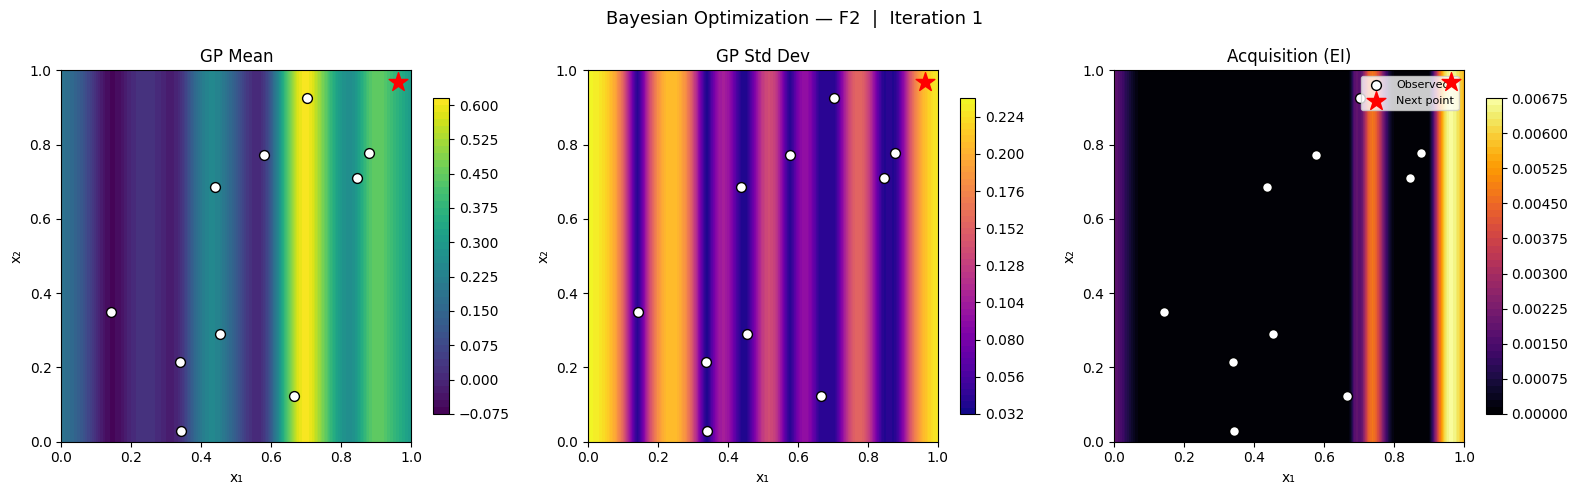

C:\Users\fakep\AppData\Local\Temp\ipykernel_37784\351953730.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   2  |  xi = 0.04250  |  acq = EI
  Current best y (log)          : 0.611205
  ✅ Suggested x CAPSTONE       : 0.734694-0.04189
  🎯 Suggested x                : [0.734694, 0.04189]
  📈 Acq. score                 : 0.006861


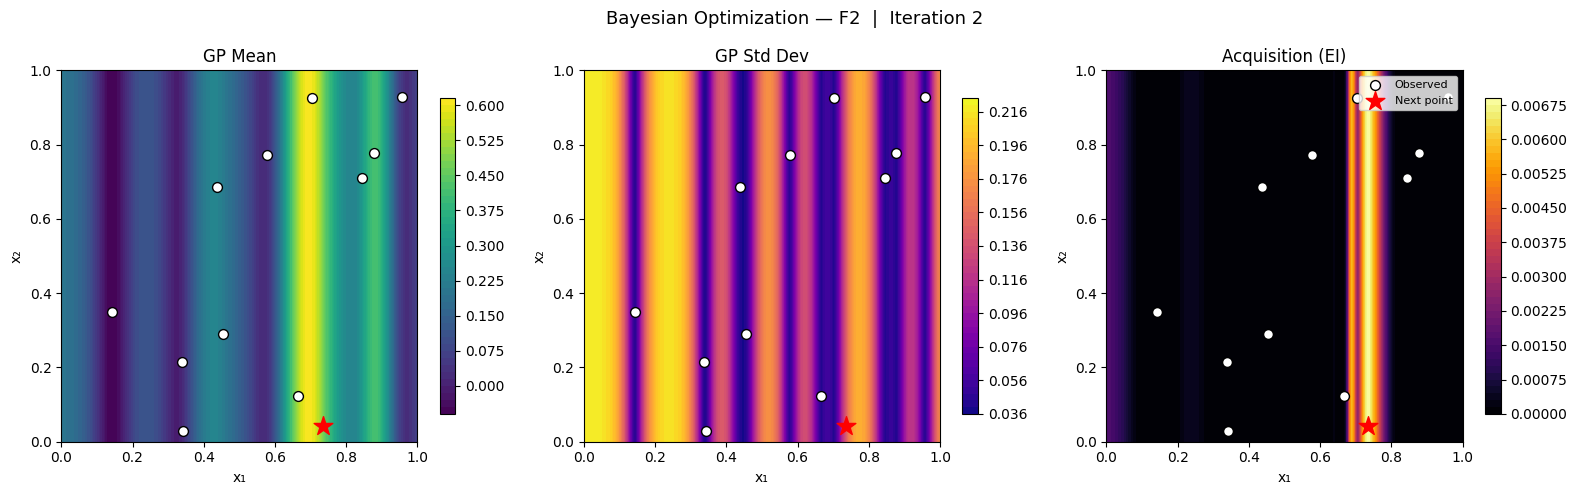

C:\Users\fakep\AppData\Local\Temp\ipykernel_37784\351953730.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   3  |  xi = 0.03612  |  acq = EI
  Current best y (log)          : 0.611205
  ✅ Suggested x CAPSTONE       : 0.693653-0.068889
  🎯 Suggested x                : [0.693653, 0.068889]
  📈 Acq. score                 : 0.004144


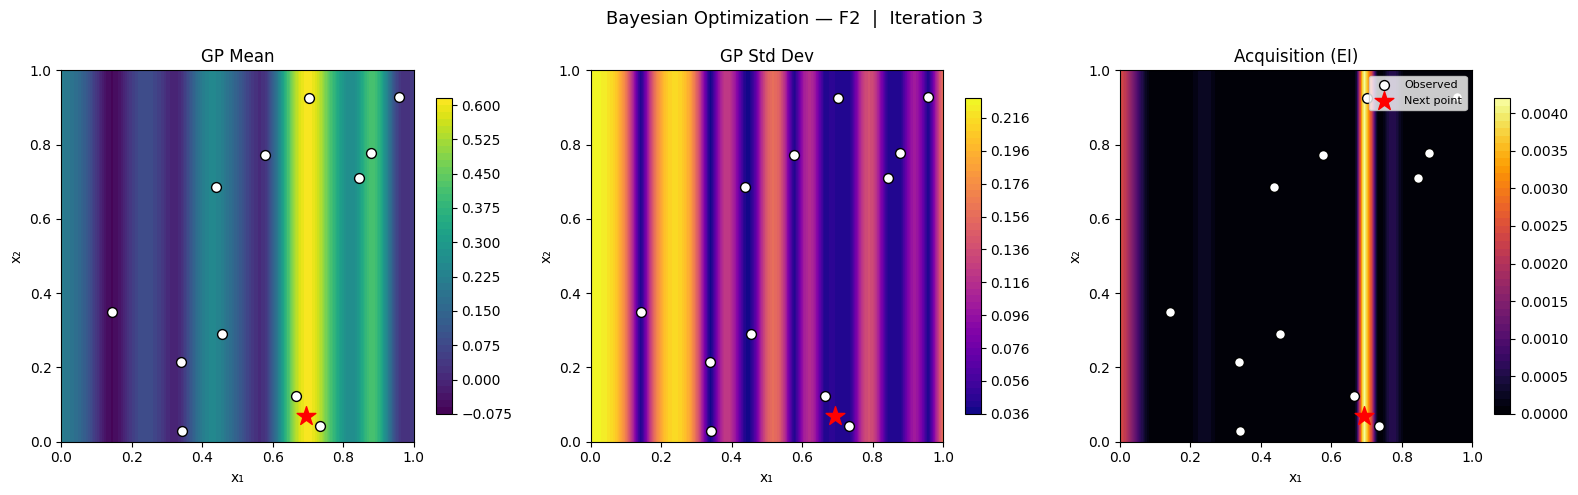

C:\Users\fakep\AppData\Local\Temp\ipykernel_37784\351953730.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   4  |  xi = 0.03071  |  acq = EI
  Current best y (log)          : 0.611205
  ✅ Suggested x CAPSTONE       : 0.0-0.990139
  🎯 Suggested x                : [0.0, 0.990139]
  📈 Acq. score                 : 0.003812


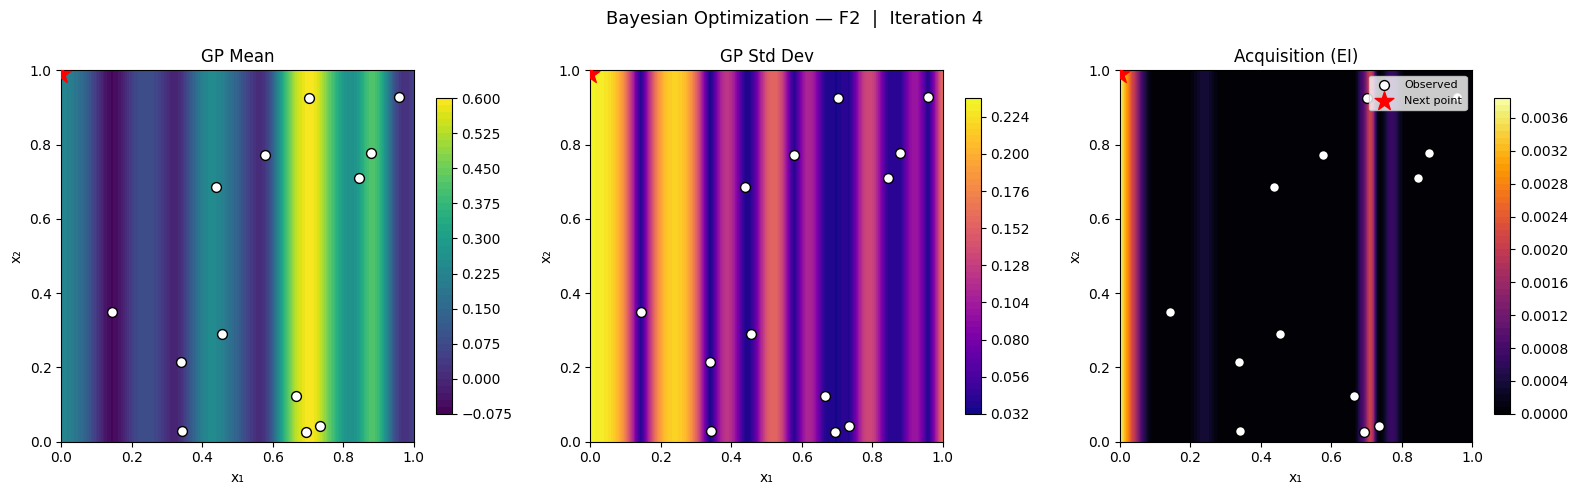

C:\Users\fakep\AppData\Local\Temp\ipykernel_37784\351953730.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   5  |  xi = 0.02610  |  acq = EI
  Current best y (log)          : 0.710498
  ✅ Suggested x CAPSTONE       : 0.716272-0.042292
  🎯 Suggested x                : [0.716272, 0.042292]
  📈 Acq. score                 : 0.002902


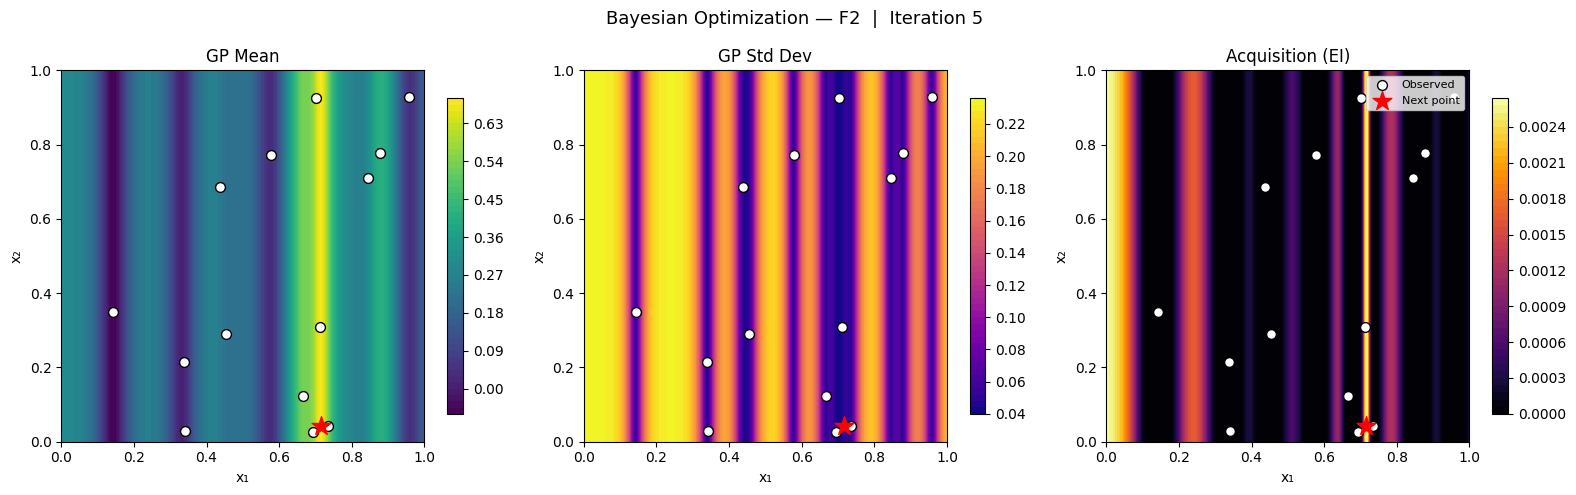

C:\Users\fakep\AppData\Local\Temp\ipykernel_37784\351953730.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   6  |  xi = 0.02219  |  acq = EI
  Current best y (log)          : 0.710498
  ✅ Suggested x CAPSTONE       : 0.0-0.745506
  🎯 Suggested x                : [0.0, 0.745506]
  📈 Acq. score                 : 0.003122


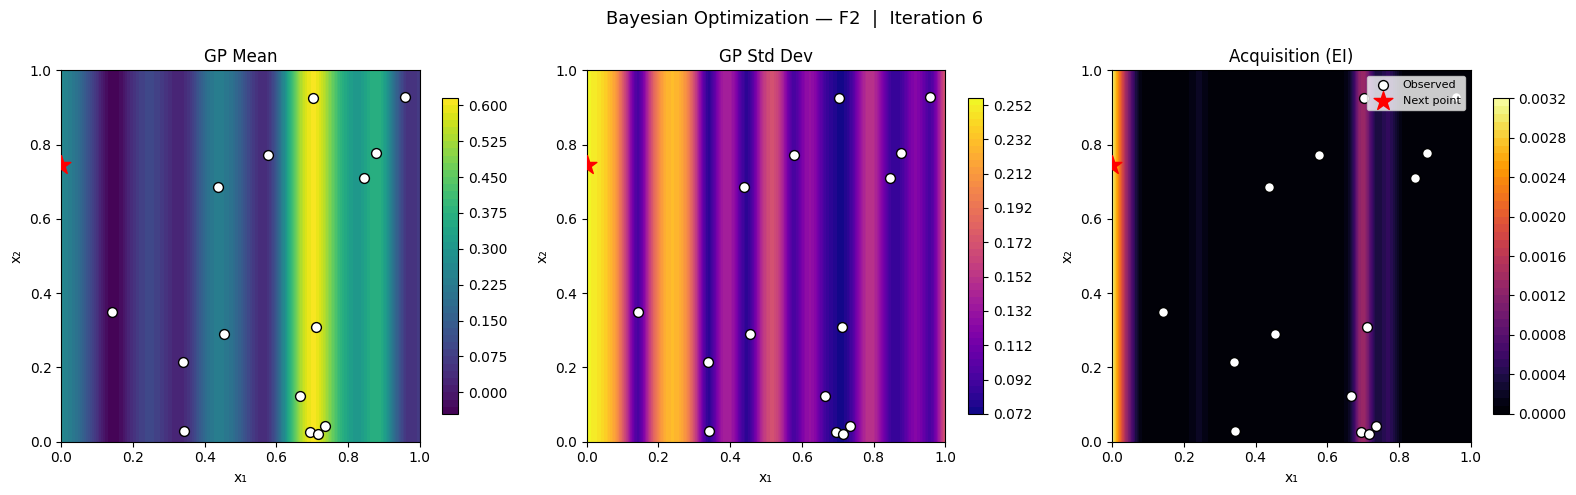

C:\Users\fakep\AppData\Local\Temp\ipykernel_37784\351953730.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   7  |  xi = 0.01886  |  acq = EI
  Current best y (log)          : 0.710498
  ✅ Suggested x CAPSTONE       : 0.699586-0.990806
  🎯 Suggested x                : [0.699586, 0.990806]
  📈 Acq. score                 : 0.001440


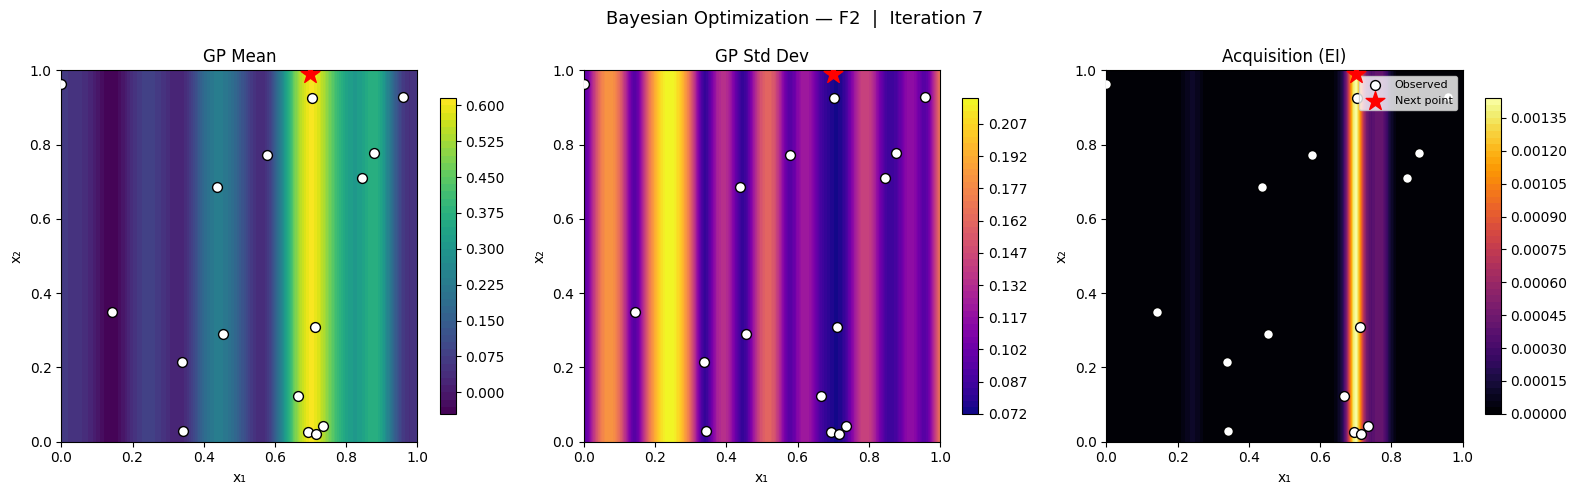

C:\Users\fakep\AppData\Local\Temp\ipykernel_37784\351953730.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   8  |  xi = 0.01603  |  acq = EI
  Current best y (log)          : 0.710498
  ✅ Suggested x CAPSTONE       : 0.702225-0.926249
  🎯 Suggested x                : [0.702225, 0.926249]
  📈 Acq. score                 : 0.001909


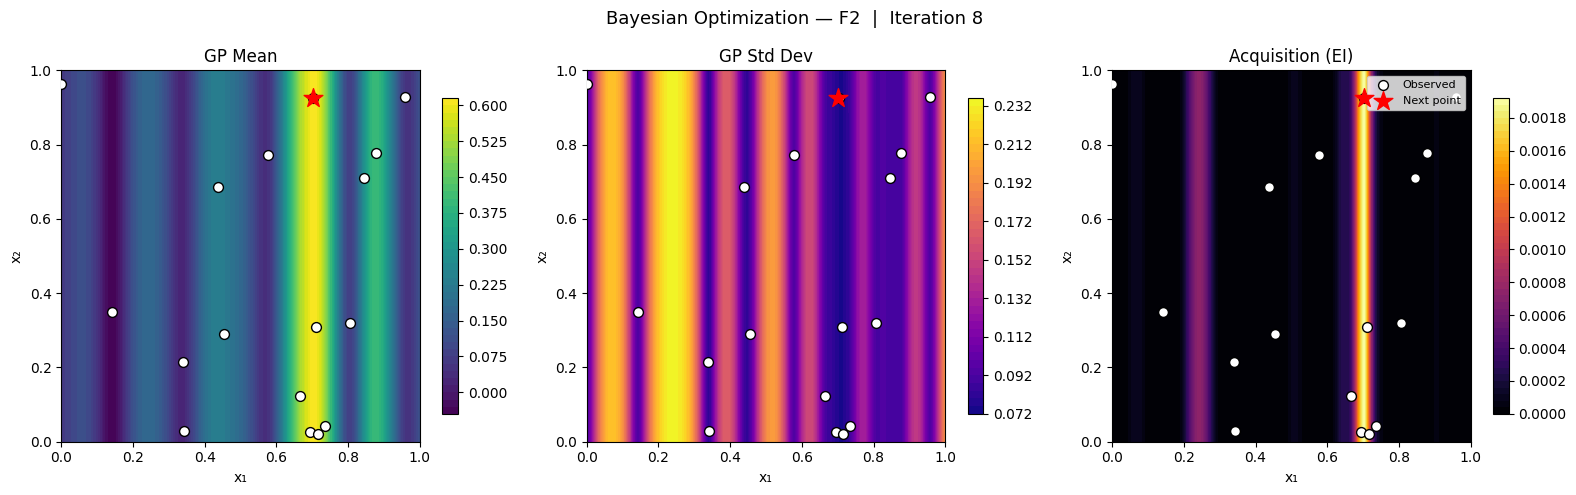

C:\Users\fakep\AppData\Local\Temp\ipykernel_37784\351953730.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration   9  |  xi = 0.01362  |  acq = EI
  Current best y (log)          : 0.710498
  ✅ Suggested x CAPSTONE       : 0.710606-0.0598
  🎯 Suggested x                : [0.710606, 0.0598]
  📈 Acq. score                 : 0.001463


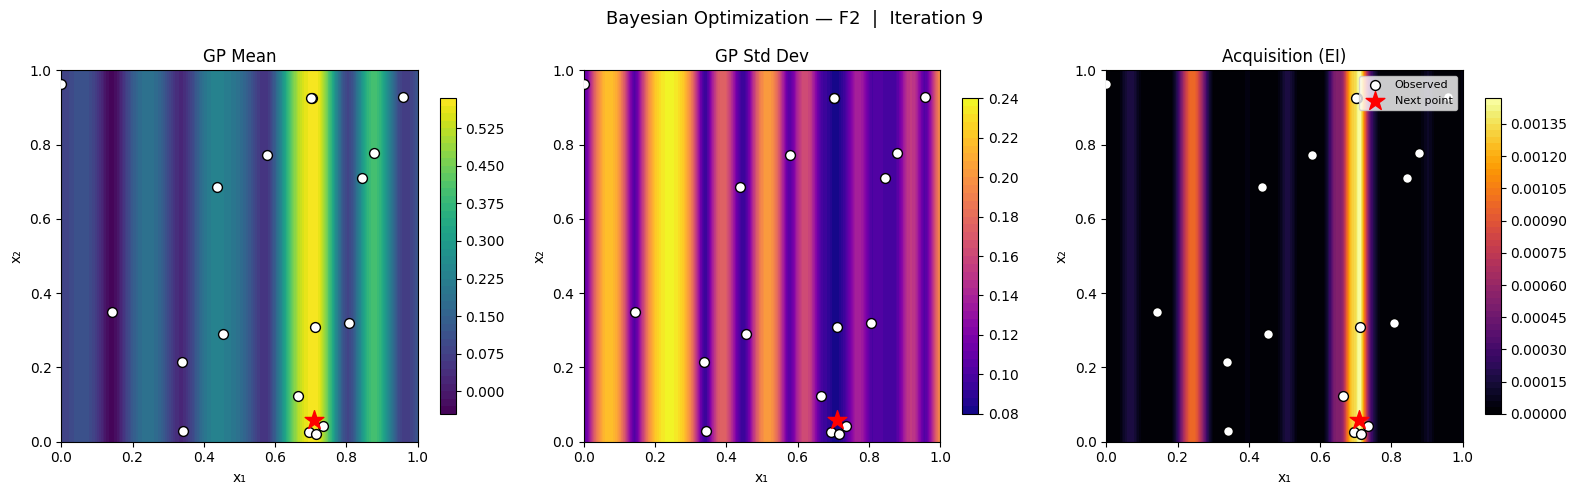

C:\Users\fakep\AppData\Local\Temp\ipykernel_37784\351953730.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration  10  |  xi = 0.01158  |  acq = EI
  Current best y (log)          : 0.710498
  ✅ Suggested x CAPSTONE       : 0.686385-0.969413
  🎯 Suggested x                : [0.686385, 0.969413]
  📈 Acq. score                 : 0.001194


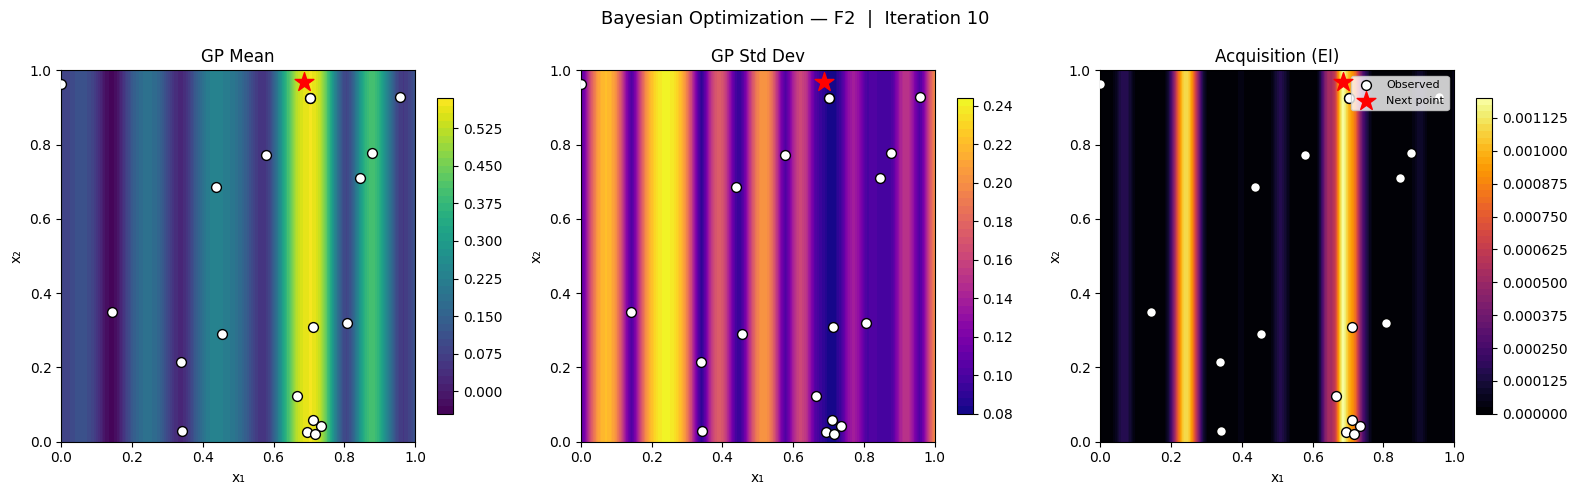

C:\Users\fakep\AppData\Local\Temp\ipykernel_37784\351953730.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration  11  |  xi = 0.00984  |  acq = EI
  Current best y (log)          : 0.710498
  ✅ Suggested x CAPSTONE       : 0.686367-0.989112
  🎯 Suggested x                : [0.686367, 0.989112]
  📈 Acq. score                 : 0.001597


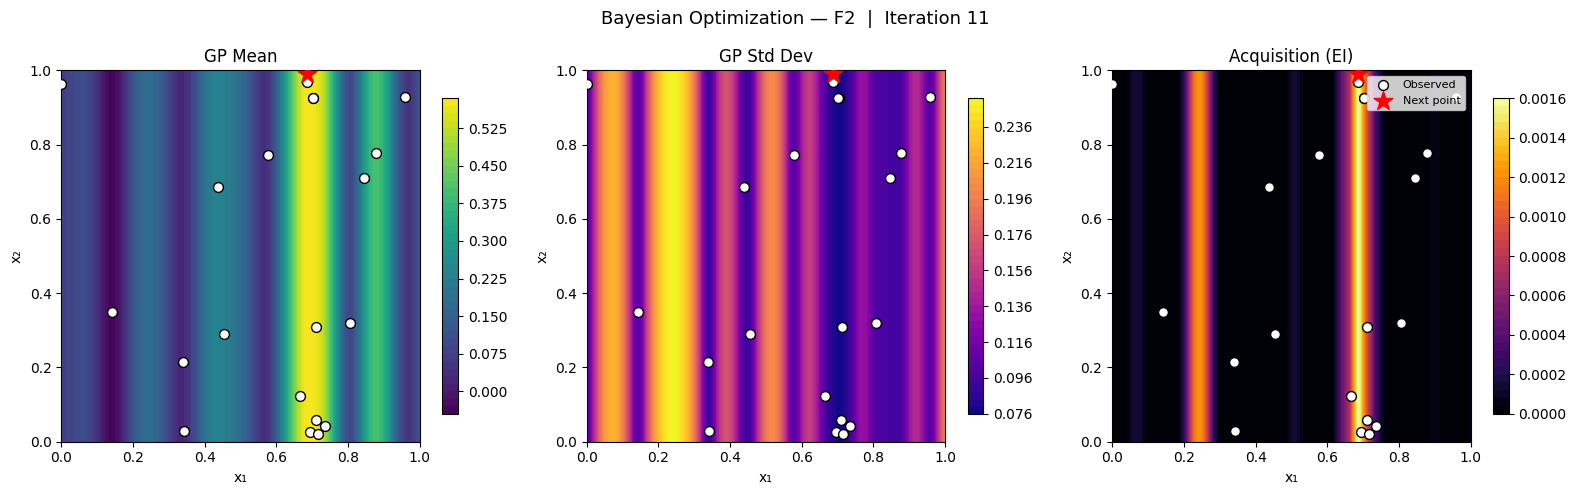

C:\Users\fakep\AppData\Local\Temp\ipykernel_37784\351953730.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand  = sampler.random(n_sobol)



  Iteration  12  |  xi = 0.00837  |  acq = EI
  Current best y (log)          : 0.710498
  ✅ Suggested x CAPSTONE       : 0.242021-0.921856
  🎯 Suggested x                : [0.242021, 0.921856]
  📈 Acq. score                 : 0.001235


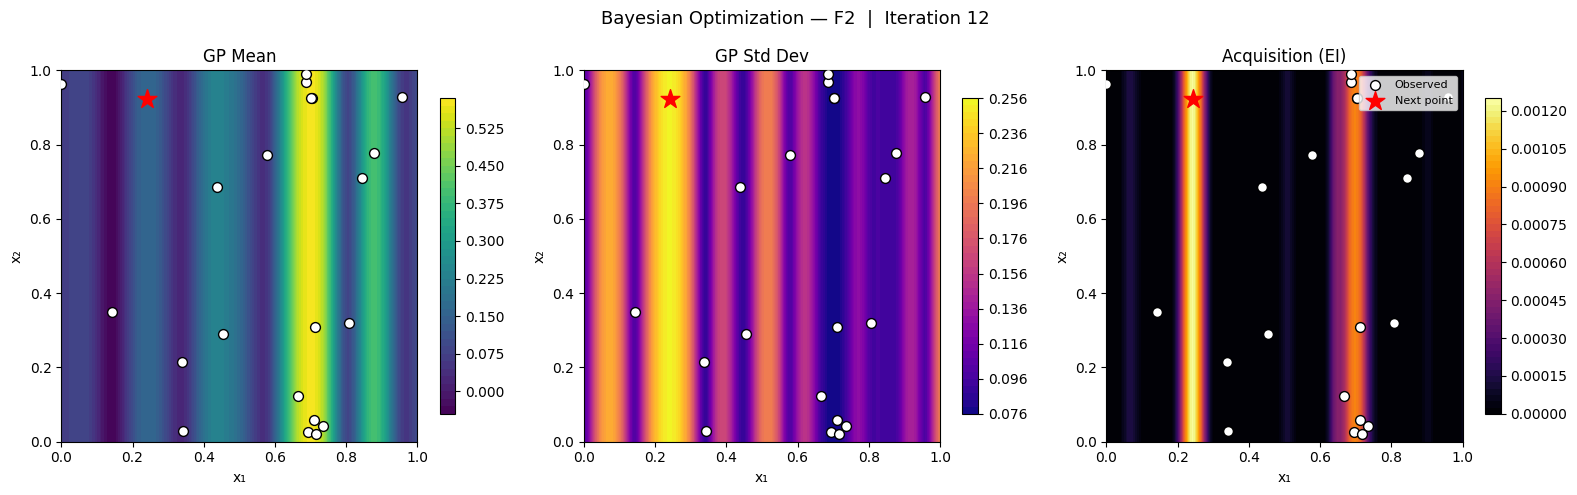

In [7]:
# ── Past Week Data ─────────────────────────────────────────────────────────────
X_new_Data = np.array([]).reshape(0, 2)
y_new_Data = np.array([])

# Week1 addition
X_new_Data = np.vstack([X_new_Data, [0.957968, 0.929069]])
y_new_Data = np.hstack([y_new_Data, 0.03633307398572442])

# Week2 addition
X_new_Data = np.vstack([X_new_Data, [0.734694, 0.041890]])
y_new_Data = np.hstack([y_new_Data, 0.5407319588408638])

# Week3 addition
X_new_Data = np.vstack([X_new_Data, [0.694017, 0.026932]])
y_new_Data = np.hstack([y_new_Data, 0.5693711885046979])

# Week4 addition
X_new_Data = np.vstack([X_new_Data, [0.711204, 0.309266]])
y_new_Data = np.hstack([y_new_Data, 0.7104976186648784])

# Week5 addition
X_new_Data = np.vstack([X_new_Data, [0.716201, 0.021965]])
y_new_Data = np.hstack([y_new_Data, 0.5133844416068506])

# Week6 addition
X_new_Data = np.vstack([X_new_Data, [0.000000, 0.962272]])
y_new_Data = np.hstack([y_new_Data, 0.057993063167378345])

# Week7 addition
X_new_Data = np.vstack([X_new_Data, [0.806514, 0.319973]])
y_new_Data = np.hstack([y_new_Data, 0.03647265797255527])

# Week8 addition
X_new_Data = np.vstack([X_new_Data, [0.702225, 0.926249]])
y_new_Data = np.hstack([y_new_Data, 0.49075338893754583])

# Week9 addition
X_new_Data = np.vstack([X_new_Data, [0.710606, 0.059800]])
y_new_Data = np.hstack([y_new_Data, 0.508385472420549])

# Week10 addition
X_new_Data = np.vstack([X_new_Data, [0.686385, 0.969413]])
y_new_Data = np.hstack([y_new_Data, 0.6314843683274326])

# Week12 addition
X_new_Data = np.vstack([X_new_Data, [0.686367, 0.989112]])
y_new_Data = np.hstack([y_new_Data, 0.5182926589401211])

# ── Configuration ─────────────────────────────────────────────────────────────
N_ITER   = len(y_new_Data)+1       # number of BO steps to run
ACQ      = "ei"    # "ei" or "ucb"
XI_INIT  = 0.05
XI_DECAY = 0.85
KAPPA    = 2.576   # only used if ACQ = "ucb"

# ── History (seeded with initial observations) ────────────────────────────────
X_obs        = X.copy()
y_obs        = y.copy()
history_best = [y_obs.max()]

for iteration in range(N_ITER):

    # 1. Fit GP on raw outputs (no transform needed for F2)
    gp    = build_gp(n_dim)
    gp.fit(X_obs, y_obs)
    y_max = y_obs.max()

    # 2. Compute adaptive xi for this iteration
    xi = adaptive_xi(iteration, xi_init=XI_INIT, decay=XI_DECAY)

    # 3. Define acquisition callable for the plot helper
    if ACQ == "ucb":
        acq_fn    = lambda X_c: upper_confidence_bound(X_c, gp, kappa=KAPPA)
        acq_label = "UCB"
    else:
        acq_fn    = lambda X_c: expected_improvement(X_c, gp, y_max, xi=xi)
        acq_label = "EI"

    # 4. Suggest next point
    x_next, score = suggest_next_point(
        gp, y_max, n_dim,
        xi=xi, acq=ACQ, kappa=KAPPA,
        seed=SEED + iteration
    )

    # 5. Print summary
    print("\n" + "="*62)
    print(f"  Iteration {iteration + 1:>3d}  |  xi = {xi:.5f}  |  acq = {acq_label}")
    print(f"  Current best y (log)          : {y_max:.6f}")
    print(f"  ✅ Suggested x CAPSTONE       : {np.round(x_next[0], 6)}-{np.round(x_next[1], 6)}")
    print(f"  🎯 Suggested x                : {np.round(x_next, 6).tolist()}")
    print(f"  📈 Acq. score                 : {score:.6f}")
    print("="*62)

    # 6. Visualise the GP and acquisition surface
    plot_gp_2d(gp, X_obs, y_obs, x_next, acq_fn,
               iteration=iteration + 1, acq_label=acq_label)

    # ── PAST WEEKS DATA ──────────────────────────────────────────────
    if iteration < len(y_new_Data):
        y_new  = y_new_Data[iteration]
        X_obs  = np.vstack([X_obs, X_new_Data[iteration]])
        y_obs  = np.append(y_obs, y_new)
        history_best.append(y_obs.max())
    # ─────────────────────────────────────────────────────────────────────────


## 8. SVM classifier on observed data

In [8]:
# Threshold: top 25% of log-transformed observations = "high"
threshold = np.percentile(y_obs, 75)
labels = (y_obs >= threshold).astype(int)  # 1 = high, 0 = low

print(f"Threshold (75th pct, log-space): {threshold:.4f}")
print(f"High-performing points : {labels.sum()} / {len(labels)}")

# Scale inputs (SVM is sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_obs)

# Soft-margin SVM with RBF kernel (handles non-linear boundaries)
# C controls margin softness: lower C = wider margin, more generalisation
# gamma='scale' = 1/(n_features * X.var()), a robust default
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
svm.fit(X_scaled, labels)

print(f"\nSVM kernel  : {svm.kernel}")
print(f"Support vectors : {svm.n_support_} (class 0 / class 1)")

Threshold (75th pct, log-space): 0.5390
High-performing points : 6 / 21

SVM kernel  : rbf
Support vectors : [9 6] (class 0 / class 1)


## 9. Visualise the SVM decision boundary alongside GP

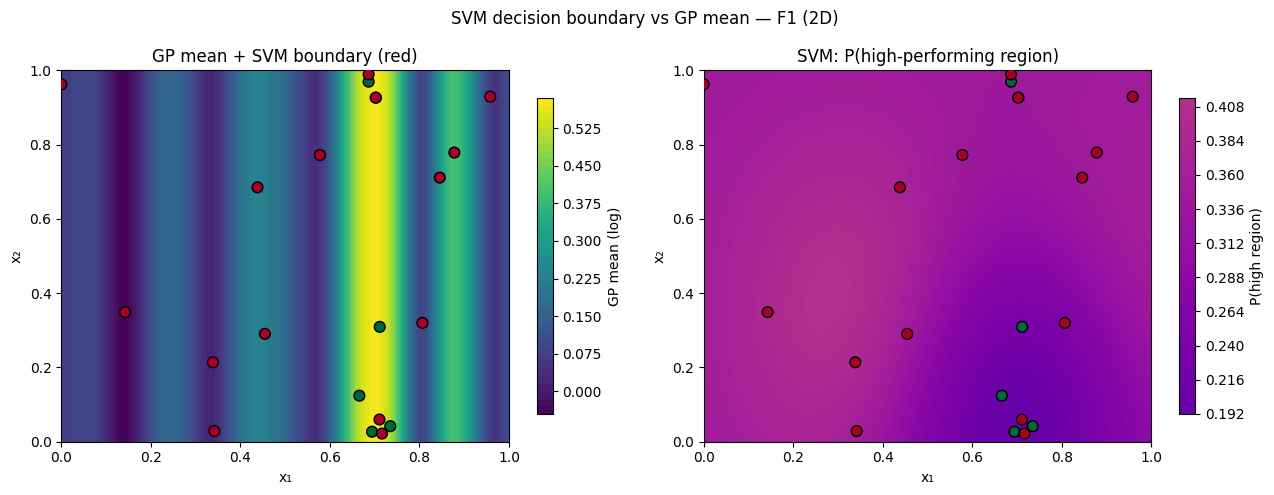

In [9]:
# ── Plot: SVM decision boundary overlaid on GP mean ──────────────────────────
resolution = 150
x1 = np.linspace(0, 1, resolution)
x2 = np.linspace(0, 1, resolution)
X1, X2 = np.meshgrid(x1, x2)
X_grid = np.column_stack([X1.ravel(), X2.ravel()])

# GP posterior mean
mu, _ = gp.predict(X_grid, return_std=True)
mu_grid = mu.reshape(resolution, resolution)

# SVM predicted class and probability of being "high"
X_grid_scaled = scaler.transform(X_grid)
svm_pred = svm.predict(X_grid_scaled).reshape(resolution, resolution)
svm_prob = svm.predict_proba(X_grid_scaled)[:, 1].reshape(resolution, resolution)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("SVM decision boundary vs GP mean — F1 (2D)", fontsize=12)

# Left: GP mean with SVM boundary
ax = axes[0]
im = ax.contourf(X1, X2, mu_grid, levels=40, cmap="viridis")
fig.colorbar(im, ax=ax, shrink=0.85, label="GP mean (log)")
ax.contour(X1, X2, svm_pred, levels=[0.5], colors="red", linewidths=2)
ax.scatter(X_obs[:, 0], X_obs[:, 1], c=labels, cmap="RdYlGn",
           edgecolors="black", s=60, zorder=5)
ax.set_title("GP mean + SVM boundary (red)")
ax.set_xlabel("x₁"); ax.set_ylabel("x₂")

# Right: SVM probability of being in high region
ax = axes[1]
im2 = ax.contourf(X1, X2, svm_prob, levels=40, cmap="plasma", vmin=0, vmax=1)
fig.colorbar(im2, ax=ax, shrink=0.85, label="P(high region)")
ax.contour(X1, X2, svm_pred, levels=[0.5], colors="white", linewidths=1.5, linestyles="--")
ax.scatter(X_obs[:, 0], X_obs[:, 1], c=labels, cmap="RdYlGn",
           edgecolors="black", s=60, zorder=5)
ax.set_title("SVM: P(high-performing region)")
ax.set_xlabel("x₁"); ax.set_ylabel("x₂")

plt.tight_layout()
plt.savefig("svm_boundary_f1.png", dpi=150)
plt.show()

## 10. SVM-constrained next point suggestion

In [10]:
# ── Constrained BO: suggest next point inside SVM "high" region ──────────────
from scipy.stats import qmc

# Generate a large Sobol candidate set
sampler = qmc.Sobol(d=n_dim, scramble=True, seed=SEED + 99)
X_cand = sampler.random(20_000)

# Keep only candidates the SVM classifies as "high"
X_cand_scaled = scaler.transform(X_cand)
svm_labels    = svm.predict(X_cand_scaled)
svm_probs     = svm.predict_proba(X_cand_scaled)[:, 1]

# Filter: inside SVM high region AND probability > 0.5
mask = (svm_labels == 1) & (svm_probs > 0.5)
X_constrained = X_cand[mask]

print(f"Candidates in high region : {mask.sum()} / {len(X_cand)} "
      f"({100*mask.mean():.1f}% of space)")

if len(X_constrained) < 10:
    # Fallback: boundary too restrictive, use full candidate set
    print("⚠️  Fewer than 10 constrained candidates — falling back to full set.")
    X_constrained = X_cand

# Score with EI inside the constrained region only
xi_constrained = adaptive_xi(N_ITER, xi_init=XI_INIT, decay=XI_DECAY)
ei_scores = expected_improvement(X_constrained, gp, y_obs.max(), xi=xi_constrained)

# Local optimisation from top-8 starts within the constrained region
starts = X_constrained[np.argsort(ei_scores)[-8:]]
bounds = [(0, 1)] * n_dim
obj    = lambda x: -expected_improvement(x, gp, y_obs.max(), xi=xi_constrained).item()

best_x_svm, best_score_svm = None, -np.inf
for x0 in starts:
    res = minimize(obj, x0=x0, bounds=bounds, method="L-BFGS-B")
    if -res.fun > best_score_svm:
        best_score_svm = -res.fun
        best_x_svm     = res.x

print(f"\n{'='*55}")
print(f"  SVM-constrained suggestion")
print(f"  Suggested x : {np.round(best_x_svm, 6).tolist()}")
print(f"  EI score    : {best_score_svm:.6f}")
print(f"  xi used     : {xi_constrained:.5f}")
print(f"  ✅ CAPSTONE format : {np.round(best_x_svm[0],6)}-{np.round(best_x_svm[1],6)}")
print(f"{'='*55}")

Candidates in high region : 0 / 20000 (0.0% of space)
⚠️  Fewer than 10 constrained candidates — falling back to full set.

  SVM-constrained suggestion
  Suggested x : [0.242023, 0.952066]
  EI score    : 0.001253
  xi used     : 0.00711
  ✅ CAPSTONE format : 0.242023-0.952066


C:\Users\fakep\AppData\Local\Temp\ipykernel_37784\1305654191.py:6: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  X_cand = sampler.random(20_000)


## 11. Neural Network Surrogate (MC Dropout)

We use a **PyTorch MLP with Monte Carlo Dropout** as a third surrogate. Unlike the GP (which has a closed-form posterior) or the SVM (which only classifies regions), the NN learns a direct regression mapping from input to output.

**Why MC Dropout for uncertainty?**
Dropout randomly zeroes neurons during training to prevent co-adaptation. At inference time, keeping dropout *active* and running multiple forward passes produces a distribution of predictions — the mean is the surrogate's prediction and the standard deviation is its uncertainty estimate (Gal & Ghahramani, 2016).

**Architecture:**
- 2 hidden layers of 32 units with ReLU activations
- Dropout rate = 0.1 between each layer
- Trained with Adam + L2 weight decay on normalised targets
- Uncertainty = std across 200 stochastic forward passes

> **F2 note:** Unlike F1, no log-transform is needed — the NN trains directly on the raw y values (normalised to N(0,1) for stable training).

In [11]:
class MCDropoutNN(nn.Module):
    """MLP with dropout kept active at inference for uncertainty quantification."""

    def __init__(self, n_in, hidden=32, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

    def mc_predict(self, x_tensor, n_samples=200):
        """n_samples stochastic forward passes → (mean, std) as numpy arrays."""
        self.train()   # keep dropout active during inference
        with torch.no_grad():
            preds = torch.stack([self(x_tensor) for _ in range(n_samples)])
        return preds.mean(0).numpy(), preds.std(0).numpy()


# ── Normalise inputs and targets ──────────────────────────────────────────────
scaler_nn = StandardScaler()
X_nn      = scaler_nn.fit_transform(X_obs)

y_nn_mean = y_obs.mean()
y_nn_std  = max(y_obs.std(), 1e-8)
y_nn      = (y_obs - y_nn_mean) / y_nn_std   # N(0,1) targets

X_t = torch.tensor(X_nn, dtype=torch.float32)
y_t = torch.tensor(y_nn, dtype=torch.float32)

# ── Train ─────────────────────────────────────────────────────────────────────
torch.manual_seed(SEED)
nn_model  = MCDropoutNN(n_dim, hidden=32, dropout=0.1)
optimizer = optim.Adam(nn_model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn   = nn.MSELoss()

nn_model.train()
for epoch in range(3000):
    optimizer.zero_grad()
    loss = loss_fn(nn_model(X_t), y_t)
    loss.backward()
    optimizer.step()

print(f"NN trained — final MSE loss: {loss.item():.6f}")

# ── Sanity check on training data ─────────────────────────────────────────────
mu_chk, sig_chk = nn_model.mc_predict(X_t, n_samples=200)
mu_chk_raw = mu_chk * y_nn_std + y_nn_mean
print(f"NN mean pred range (raw) : [{mu_chk_raw.min():.4f}, {mu_chk_raw.max():.4f}]")
print(f"NN uncertainty std range : [{sig_chk.min():.4f},  {sig_chk.max():.4f}]")

NN trained — final MSE loss: 0.059998
NN mean pred range (raw) : [-0.0626, 0.6852]
NN uncertainty std range : [0.0973,  0.3299]


## 12. NN-constrained next point suggestion

We define EI using the MC-Dropout NN's predicted mean (μ) and standard deviation (σ), then run the same Sobol + L-BFGS-B optimisation used for the GP.

In [12]:
def expected_improvement_nn(X_cand, nn_model, scaler_nn, y_nn_mean, y_nn_std,
                             y_max, xi=0.01, n_mc=200):
    """EI using MC-Dropout NN surrogate — operates on raw (untransformed) y values."""
    X_cand   = np.atleast_2d(X_cand)
    X_scaled = scaler_nn.transform(X_cand)
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    mu_norm, sigma_norm = nn_model.mc_predict(X_tensor, n_samples=n_mc)
    # Un-normalise back to raw y-space
    mu    = mu_norm  * y_nn_std + y_nn_mean
    sigma = np.maximum(sigma_norm * y_nn_std, 1e-8)
    imp   = mu - y_max - xi
    Z     = imp / sigma
    ei    = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma <= 1e-8] = 0.0
    return ei


xi_nn = adaptive_xi(N_ITER, xi_init=XI_INIT, decay=XI_DECAY)

# Sobol candidates — power-of-2 size avoids the UserWarning
sampler_nn   = qmc.Sobol(d=n_dim, scramble=True, seed=SEED + 199)
X_cand_nn    = sampler_nn.random(16_384)

ei_nn_scores = expected_improvement_nn(
    X_cand_nn, nn_model, scaler_nn, y_nn_mean, y_nn_std, y_obs.max(), xi=xi_nn
)

# Local optimisation from top-8 Sobol starts
starts_nn = X_cand_nn[np.argsort(ei_nn_scores)[-8:]]
obj_nn    = lambda x: -expected_improvement_nn(
    x, nn_model, scaler_nn, y_nn_mean, y_nn_std, y_obs.max(), xi=xi_nn
).item()

best_x_nn, best_score_nn = None, -np.inf
for x0 in starts_nn:
    res = minimize(obj_nn, x0=x0, bounds=[(0, 1)] * n_dim, method="L-BFGS-B")
    if -res.fun > best_score_nn:
        best_score_nn = -res.fun
        best_x_nn     = res.x

print(f"\n{'='*55}")
print(f"  NN (MC Dropout) suggestion")
print(f"  Suggested x : {np.round(best_x_nn, 6).tolist()}")
print(f"  EI score    : {best_score_nn:.6f}")
print(f"  xi used     : {xi_nn:.5f}")
print(f"  ✅ CAPSTONE format : {np.round(best_x_nn[0],6)}-{np.round(best_x_nn[1],6)}")
print(f"{'='*55}")


  NN (MC Dropout) suggestion
  Suggested x : [0.712451, 0.305316]
  EI score    : 0.008320
  xi used     : 0.00711
  ✅ CAPSTONE format : 0.712451-0.305316


## 13. Visualise the NN surrogate surface

Three panels mirror the GP visualisation (Section 6): **NN mean**, **NN uncertainty (std)**, and **NN EI**. This lets you directly compare how the NN and GP view the same landscape.

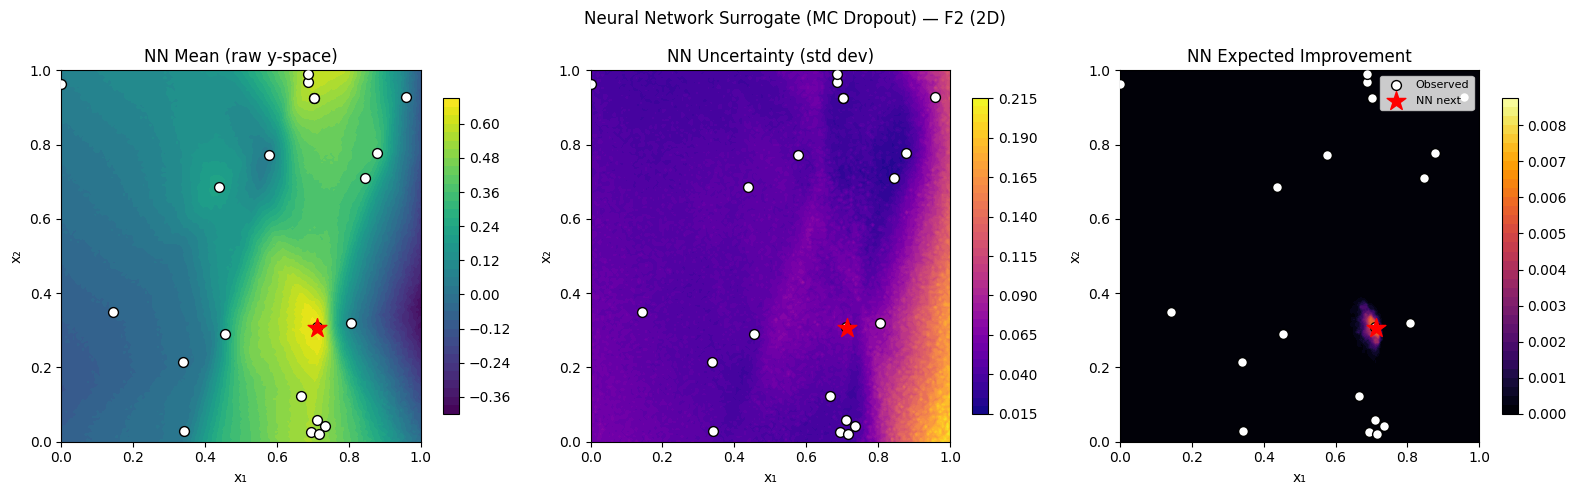

In [13]:
resolution = 150
x1 = np.linspace(0, 1, resolution)
x2 = np.linspace(0, 1, resolution)
X1, X2  = np.meshgrid(x1, x2)
X_grid  = np.column_stack([X1.ravel(), X2.ravel()])

X_grid_scaled = scaler_nn.transform(X_grid)
X_grid_t      = torch.tensor(X_grid_scaled, dtype=torch.float32)
mu_norm_grid, sigma_norm_grid = nn_model.mc_predict(X_grid_t, n_samples=200)

nn_mean_grid = (mu_norm_grid * y_nn_std + y_nn_mean).reshape(resolution, resolution)
nn_std_grid  = (sigma_norm_grid * y_nn_std).reshape(resolution, resolution)
ei_nn_grid   = expected_improvement_nn(
    X_grid, nn_model, scaler_nn, y_nn_mean, y_nn_std, y_obs.max(), xi=xi_nn, n_mc=200
).reshape(resolution, resolution)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Neural Network Surrogate (MC Dropout) — F2 (2D)", fontsize=12)

panels = [
    (nn_mean_grid, "NN Mean (raw y-space)",     "viridis"),
    (nn_std_grid,  "NN Uncertainty (std dev)",  "plasma"),
    (ei_nn_grid,   "NN Expected Improvement",   "inferno"),
]

for ax, (data, title, cmap) in zip(axes, panels):
    im = ax.contourf(X1, X2, data, levels=40, cmap=cmap)
    fig.colorbar(im, ax=ax, shrink=0.85)
    ax.scatter(X_obs[:, 0], X_obs[:, 1], c="white", edgecolors="black",
               s=50, zorder=5, label="Observed")
    ax.scatter(*best_x_nn, c="red", marker="*", s=200, zorder=6, label="NN next")
    ax.set_title(title)
    ax.set_xlabel("x₁"); ax.set_ylabel("x₂")

axes[2].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("nn_surrogate_f2.png", dpi=150)
plt.show()

## 14. Compare all three models: GP vs SVM vs NN

We compare the **EI score** and **suggested next point** from each surrogate:

| Model | Surrogate type | Uncertainty source |
|---|---|---|
| **GP** | Matérn 5/2 kernel | Bayesian posterior (exact) |
| **SVM** | RBF classifier | P(high region) — filters candidates |
| **NN** | MC-Dropout MLP | 200 stochastic forward passes |

A bar chart visualises the EI values directly, and pairwise distances quantify agreement between the three suggestions.

Model                                       Suggested x           EI
----------------------------------------------------------------------
GP (unconstrained)                 [0.242021, 0.921856]     0.001235
SVM-constrained                    [0.242023, 0.952066]     0.001253
NN (MC Dropout)                    [0.712451, 0.305316]     0.008320

GP  ↔ SVM distance : 0.0302
GP  ↔ NN  distance : 0.7755
SVM ↔ NN  distance : 0.7997

❗ Strong disagreement — models see different promising regions; trust the GP.


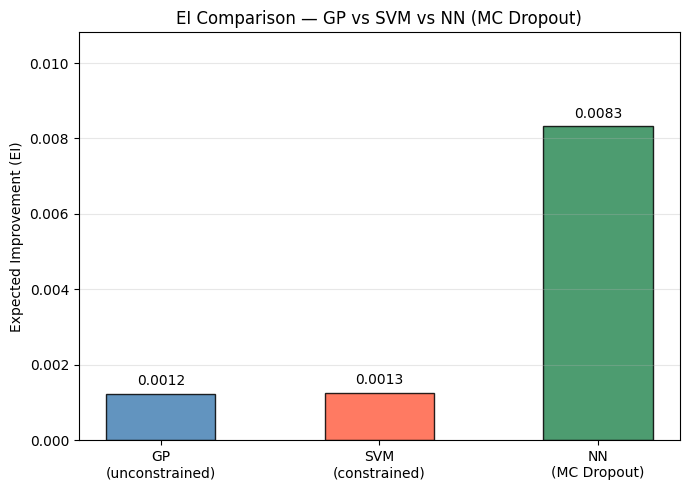

In [14]:
# ── Summary table ─────────────────────────────────────────────────────────────
print(f"{'Model':<24} {'Suggested x':>30}   {'EI':>10}")
print("-" * 70)
print(f"{'GP (unconstrained)':<24} {str(np.round(x_next, 6).tolist()):>30}   {score:>10.6f}")
print(f"{'SVM-constrained':<24} {str(np.round(best_x_svm, 6).tolist()):>30}   {best_score_svm:>10.6f}")
print(f"{'NN (MC Dropout)':<24} {str(np.round(best_x_nn, 6).tolist()):>30}   {best_score_nn:>10.6f}")

# ── Pairwise distances ────────────────────────────────────────────────────────
dist_gp_svm = np.linalg.norm(x_next - best_x_svm)
dist_gp_nn  = np.linalg.norm(x_next - best_x_nn)
dist_svm_nn = np.linalg.norm(best_x_svm - best_x_nn)

print(f"\nGP  ↔ SVM distance : {dist_gp_svm:.4f}")
print(f"GP  ↔ NN  distance : {dist_gp_nn:.4f}")
print(f"SVM ↔ NN  distance : {dist_svm_nn:.4f}")

# ── Consensus check ───────────────────────────────────────────────────────────
suggestions = [x_next, best_x_svm, best_x_nn]
centroid    = np.mean(suggestions, axis=0)
max_dev     = max(np.linalg.norm(s - centroid) for s in suggestions)

if max_dev < 0.05:
    print("\n✅ All three models agree — very high confidence in this region.")
elif max_dev < 0.15:
    print("\n⚠️  Mild disagreement — GP posterior is most principled; prefer GP suggestion.")
else:
    print("\n❗ Strong disagreement — models see different promising regions; trust the GP.")

# ── Bar chart: EI scores across the three surrogates ─────────────────────────
labels_bar    = ["GP\n(unconstrained)", "SVM\n(constrained)", "NN\n(MC Dropout)"]
ei_scores_bar = [score, best_score_svm, best_score_nn]
colors_bar    = ["steelblue", "tomato", "seagreen"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels_bar, ei_scores_bar, color=colors_bar,
              edgecolor="black", alpha=0.85, width=0.5)
ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=10)
ax.set_ylabel("Expected Improvement (EI)")
ax.set_title("EI Comparison — GP vs SVM vs NN (MC Dropout)")
ax.set_ylim(0, max(ei_scores_bar) * 1.3)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("ei_comparison_three_models_f2.png", dpi=150)
plt.show()

## 15. Hyperparameter Sensitivity — ξ (xi) Exploration (Module 18)

Module 18 identifies **ξ (xi)** as the key hyperparameter of the EI acquisition function controlling the exploration–exploitation trade-off. Rather than relying solely on the adaptive decay schedule, this section applies a **coarse grid search** over ξ — the simplest tuning strategy from Mini-lesson 18.5.

By scanning ξ ∈ {0.001 … 0.5} with the GP already fitted on all 2D observations, we can:
- Confirm the adaptive ξ is in a sensible range for the current dataset
- See how sensitive the suggested query is to this hyperparameter
- Decide whether to override the schedule if the function appears nearly converged (small ξ) or still widely uncertain (large ξ)

In [15]:
# ── ξ (xi) grid search — treating xi as a hyperparameter to tune ──────────────────
print('GP suggestion sensitivity to xi (exploration-exploitation hyperparameter):')
print(f"{'xi':>8}  {'EI score':>12}  Suggested x (CAPSTONE format)")
print('-' * 85)

xi_grid    = [0.001, 0.01, 0.05, 0.1, 0.5]
xi_current = adaptive_xi(N_ITER, xi_init=XI_INIT, decay=XI_DECAY)

for xi_test in xi_grid:
    sampler_s  = qmc.Sobol(d=n_dim, scramble=True, seed=SEED + 888)
    X_c_s      = sampler_s.random(8_192)          # 2^13 quick scan
    scores_s   = expected_improvement(X_c_s, gp, y_obs.max(), xi=xi_test)
    starts_s   = X_c_s[np.argsort(scores_s)[-5:]]
    obj_s      = lambda x, xi=xi_test: -expected_improvement(x, gp, y_obs.max(), xi=xi).item()
    bx_s, bs_s = None, -np.inf
    for x0 in starts_s:
        r = minimize(obj_s, x0=x0, bounds=[(0, 1)] * n_dim, method='L-BFGS-B')
        if -r.fun > bs_s: bs_s = -r.fun; bx_s = r.x
    capstone_s = '-'.join(f'{v:.6f}' for v in bx_s)
    marker     = '  <- adaptive (current)' if abs(xi_test - xi_current) < 0.02 else ''
    print(f'  {xi_test:>6.3f}  {bs_s:>12.6f}  {capstone_s}{marker}')

print(f'\nAdaptive xi at iteration {N_ITER}: {xi_current:.5f}  '
      f'(xi_init={XI_INIT}, decay={XI_DECAY}^{N_ITER})')

GP suggestion sensitivity to xi (exploration-exploitation hyperparameter):
      xi      EI score  Suggested x (CAPSTONE format)
-------------------------------------------------------------------------------------
   0.001      0.001342  0.242030-0.800990  <- adaptive (current)
   0.010      0.001213  0.242019-0.800990  <- adaptive (current)
   0.050      0.000765  0.241974-0.800990
   0.100      0.000417  0.241920-0.769274
   0.500      0.000001  0.241630-0.472014

Adaptive xi at iteration 12: 0.00711  (xi_init=0.05, decay=0.85^12)


## 16. GP Kernel Diagnostics (Module 18)

The GP kernel hyperparameters are fitted by maximising the log-marginal-likelihood. Inspecting them connects to Module 18's insight that **length scales act as feature importance scores**:

- **Small length scale** → function changes quickly along that axis → high sensitivity → important dimension
- **Large length scale** → function is nearly flat along that axis → low sensitivity → potentially irrelevant

This mirrors Module 18's note that random search works well when only a few hyperparameters heavily influence performance — the same may be true of our 2D function's input dimensions. A large length-scale disparity is a signal to focus future queries on the most sensitive dimensions.

Fitted GP kernel hyperparameters (F2, 2D):
  Amplitude  s2   : 1.0623
  Noise level     : 8.12e-02

Per-dimension length scales:
  x1:    0.0617  XXXXX
  x2: 1000.0000  XXXXXXXXXXXXXXXXXXXXXXXXXXX


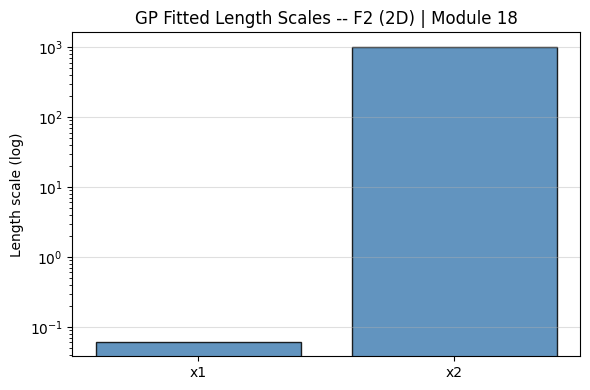

In [16]:
# ── GP fitted kernel hyperparameters ─────────────────────────────────────────────
fitted_ls = gp.kernel_.k1.k2.length_scale
noise_lv  = gp.kernel_.k2.noise_level
amplitude = gp.kernel_.k1.k1.constant_value
ls_arr    = np.array(fitted_ls)
dim_lbls  = [f'x{i+1}' for i in range(n_dim)]

print(f'Fitted GP kernel hyperparameters (F2, {n_dim}D):')
print(f'  Amplitude  s2   : {amplitude:.4f}')
print(f'  Noise level     : {noise_lv:.2e}')
print('\nPer-dimension length scales:')
for lbl, ls in zip(dim_lbls, ls_arr):
    bar = 'X' * max(1, min(int(np.log10(ls + 1e-8) * 5 + 12), 35))
    print(f'  {lbl}: {ls:9.4f}  {bar}')

if n_dim >= 3:
    idx_min, idx_max = ls_arr.argmin(), ls_arr.argmax()
    ratio = ls_arr[idx_max] / (ls_arr[idx_min] + 1e-8)
    print(f'\nMost  sensitive dim : {dim_lbls[idx_min]} (ls={ls_arr[idx_min]:.4f})')
    print(f'Least sensitive dim : {dim_lbls[idx_max]} (ls={ls_arr[idx_max]:.4f})')
    if ratio > 10:
        print(f'\n[!] Length scale ratio {ratio:.0f}x -- function may be effectively '
              f'lower-dimensional. Focus future queries around {dim_lbls[idx_min]}.')
    else:
        print(f'\n[OK] Length scale ratio {ratio:.1f}x -- all dimensions contribute similarly.')

fig, ax = plt.subplots(figsize=(max(6, n_dim * 1.3), 4))
ax.bar(dim_lbls, ls_arr, color='steelblue', edgecolor='black', alpha=0.85)
ax.set_yscale('log')
ax.set_ylabel('Length scale (log)')
ax.set_title(f'GP Fitted Length Scales -- F2 ({n_dim}D) | Module 18')
ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('length_scales_module18_f2.png', dpi=150)
plt.show()

## 17. Convergence Plot

After running multiple iterations with real evaluations, this cell plots the **best observed value over time** — the primary diagnostic for whether the optimizer is making progress. A well-functioning BO loop should show a monotonically non-decreasing curve that flattens as it approaches the true optimum.

Uncomment and run after completing multiple BO iterations.

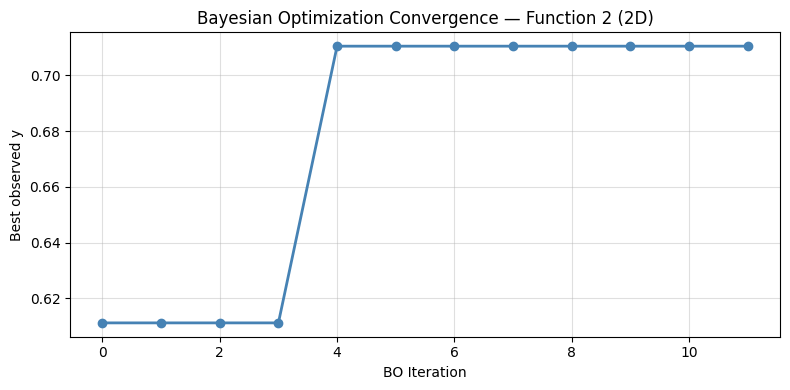

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(range(len(history_best)), history_best, marker="o", linewidth=2, color="steelblue")
plt.xlabel("BO Iteration")
plt.ylabel("Best observed y")
plt.title("Bayesian Optimization Convergence — Function 2 (2D)")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("convergence_f2.png", dpi=150)
plt.show()

Week 2 Recommandation
Recommendation: Switch to EI (or reduce KAPPA)

Reasons specific to your F2 setup:

You're already near the top of the range. Your current best is 0.6112 and the full y range is [-0.07, 0.61] — you're essentially at the observed maximum. EI will focus on improving from this point rather than wandering.

UCB with κ=2.576 is very aggressive. That's the 99% CI level. Your Week 1 UCB suggestion [0.958, 0.929] returned y=0.036 — a big step backward, suggesting UCB sent you into an unexplored but bad region.

Only 11 points in 2D — sparse, but with a good incumbent, EI with adaptive xi (starting at 0.05, decaying) will still explore while biasing toward improvement.